In [1]:
import pandas as pd
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

## Merge example 1 (SQL joins)

In [2]:
df_jobs = pd.DataFrame({
    "job_id":[1, 2, 3, 4, 5],
    "job_title":["Data Scientist", "Software Engineer", "Product Manager", "Marketing Director", "HR Manager"],
    "company_name":["Google", "Microsoft", "Apple", "Nike", "Starbucks"],
    "job_location":["Mountain View, CA", "Redmond, WA", "Cupertino, CA", "Beaverton, OR", "Seattle, WA"],
})

df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [3]:
df_companies = pd.DataFrame({
    "company_name":["Google", "Microsoft", "Apple", "Nike", "Starbucks"],
    "industry":["Technology", "Technology", "Technology", "Apparel", "Food & Beverage"],
    "company_size":["100,000+", "100,000+", "100,000+", "75,000+", "346,000+"]
})

df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [6]:
merge_example = (
    df_jobs
    .merge(df_companies, on="company_name")
    .set_index("job_id")
)

merge_example

,job_title,company_name,job_location,industry,company_size
job_id,,,,,
1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


## Merge example 2 (SQL joins)

In [16]:
import calendar

# retrive the top 3 most common data jobs
top_job_postings = df["job_title_short"].value_counts().head(3).index

# filter dataframe to have only United States job postings
job_postings_us = df.loc[
    (df["job_country"] == "United States") & (df["job_title_short"].isin(top_job_postings)),
    :
]

# extract the months from the job_posted_date column
job_postings_us["job_posted_month"] = job_postings_us["job_posted_date"].dt.month

# create aggregation
aggregation = job_postings_us.pivot_table(
    index="job_posted_month", 
    columns="job_title_short",
    aggfunc="size"
)

aggregation.index = [calendar.month_abbr[x] for x in aggregation.index]
aggregation.index.name = "job_posted_month"

aggregation

job_title_short,Data Analyst,Data Engineer,Data Scientist
job_posted_month,,,
Jan,8494,2655,6915
Feb,6124,3060,4956
Mar,6218,3183,4779
Apr,6049,2801,4867
May,4993,2976,4377
Jun,5683,2893,4645
Jul,5201,2570,4876
Aug,6634,3269,6318
Sep,4639,3224,4568


In [23]:
# get second dataset to perform merge

extra_jobs = pd.read_csv("https://lukeb.co/software_csv")
extra_jobs.index = [x for x in range(1, 13)]
extra_jobs.index = [calendar.month_abbr[x] for x in extra_jobs.index]
extra_jobs.drop(columns="job_posted_month", inplace=True)
extra_jobs.index.name = "job_posted_month"
extra_jobs

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
Jan,13619,9827,5108,4348
Feb,11456,9116,7298,4284
Mar,11102,8178,5814,4159
Apr,14037,9209,7232,4220
May,12126,8864,6718,4980
Jun,12003,8065,5902,4781
Jul,11914,8061,6839,4344
Aug,11571,8191,7413,4104
Sep,14016,8447,6139,4094


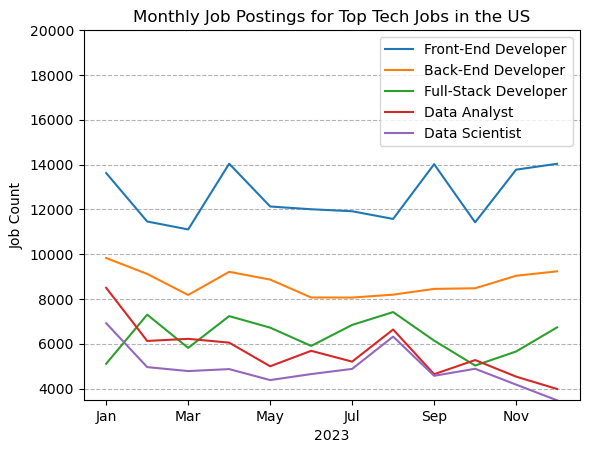

In [50]:
import matplotlib.pyplot as plt

# merge both

tech_jobs_data = aggregation.merge(extra_jobs, on="job_posted_month")

top_5_jobs = (
    tech_jobs_data
    .sum()
    .sort_values(ascending=False)
    .head()
    .index
)

tech_jobs_data = tech_jobs_data.loc[
    :,
    top_5_jobs
]

tech_jobs_data.plot()
plt.xlabel("2023")
plt.ylabel("Job Count")
plt.title("Monthly Job Postings for Top Tech Jobs in the US")
plt.ylim(3500, 20000)
plt.grid(True, axis="y", color="gray", alpha=0.6, linestyle="--")
plt.show()